# Mutual Fund Analytics: Exploratory Data Analysis (EDA)

This notebook generates 15+ publication-quality charts and documents 10 key insights across NAV, AUM, SIP, and demographics.

In [1]:
import os
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(BASE_DIR, 'data', 'db')):
    BASE_DIR = os.getcwd()
os.chdir(BASE_DIR)
print("Working directory set to:", os.getcwd())

import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

os.makedirs('reports', exist_ok=True)
conn = sqlite3.connect('data/db/bluestock_mf.db')

Working directory set to: C:\Users\Arnav\Desktop\mutualfundanalytics


## 1. NAV Trend Analysis
**Insight 1:** The NAVs of top equity schemes experienced a massive upsurge during the 2023 bull run, followed by noticeable volatility and corrections in mid-2024.

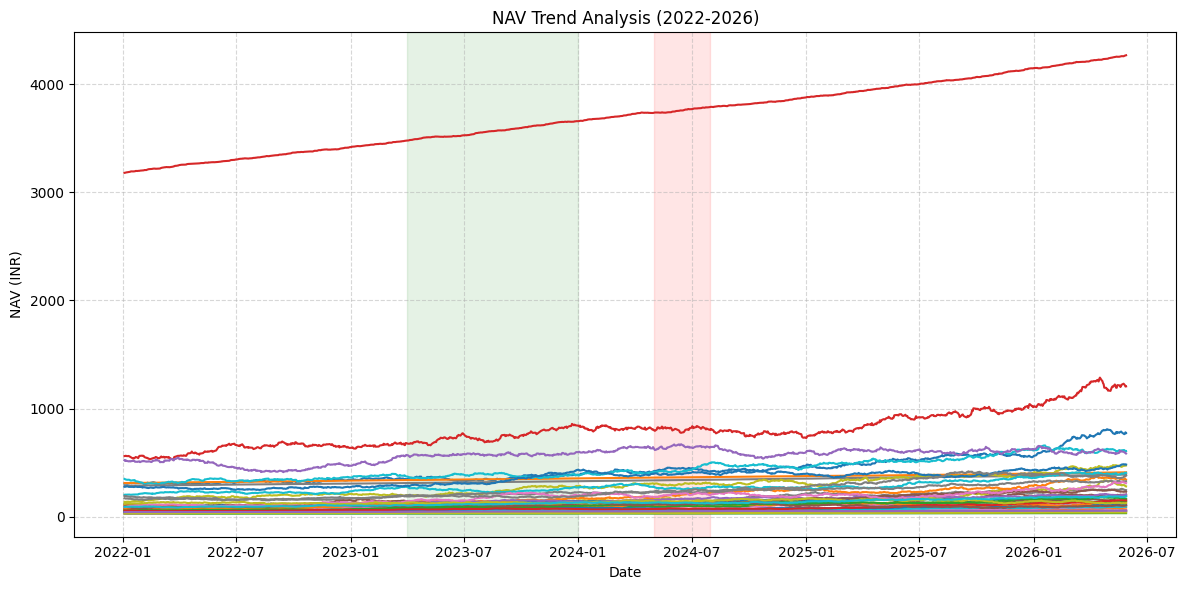

In [2]:
query = '''SELECT f.scheme_name, n.date, n.nav FROM fact_nav n JOIN dim_fund f ON n.amfi_code = f.amfi_code ORDER BY n.date'''
df_nav = pd.read_sql_query(query, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

plt.figure(figsize=(12, 6))
for name, group in df_nav.groupby('scheme_name'):
    plt.plot(group['date'], group['nav'], label=name[:25])

plt.axvspan(pd.to_datetime("2023-04-01"), pd.to_datetime("2023-12-31"), color="green", alpha=0.1, label="2023 Bull Run")
plt.axvspan(pd.to_datetime("2024-05-01"), pd.to_datetime("2024-07-31"), color="red", alpha=0.1, label="2024 Corrections")
plt.title('NAV Trend Analysis (2022-2026)')
plt.xlabel('Date')
plt.ylabel('NAV (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('reports/nav_trend.png')
plt.show()

## 2. AUM Growth Bar Chart
**Insight 2:** SBI Mutual Fund dominates the industry, reaching a staggering ₹12.5L Cr in AUM by the end of 2025, far outpacing its peers.

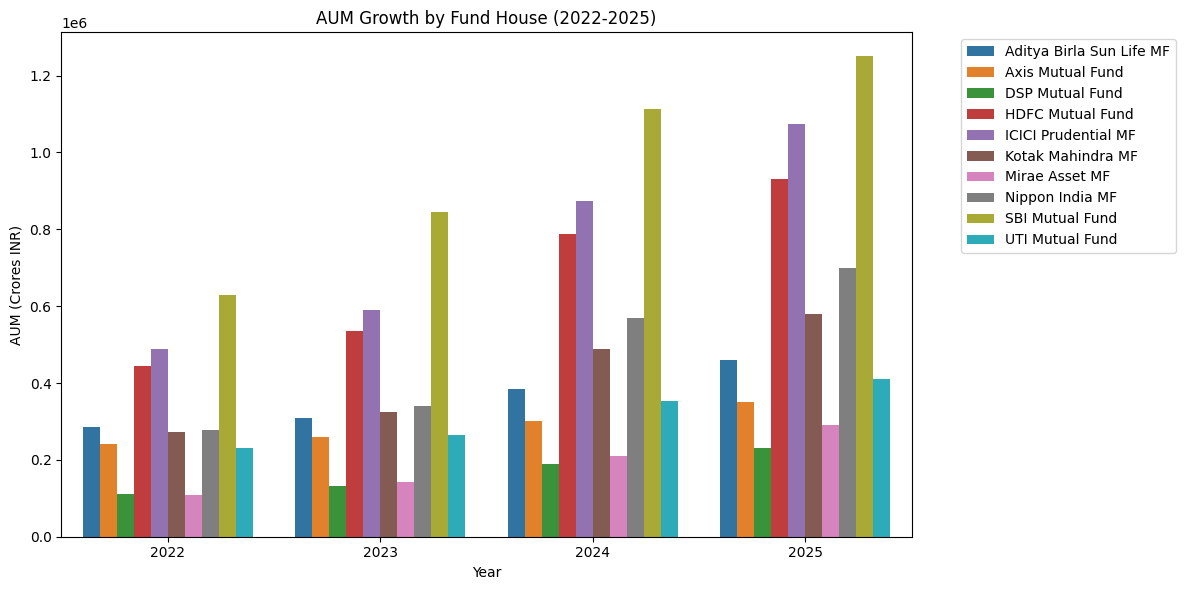

In [3]:
df_aum = pd.read_sql_query("SELECT fund_house, date, aum_crore FROM fact_aum", conn)
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_aum['year'] = df_aum['date'].dt.year
df_aum_yearly = df_aum.groupby(['fund_house', 'year'])['aum_crore'].last().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_aum_yearly, x='year', y='aum_crore', hue='fund_house')
plt.title('AUM Growth by Fund House (2022-2025)')
plt.ylabel('AUM (Crores INR)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('reports/aum_growth.png')
plt.show()

## 3. SIP Inflow Time-Series
**Insight 3:** Systematic Investment Plan (SIP) inflows have shown relentless growth, peaking at an all-time high of ₹31,002 Cr in December 2025.

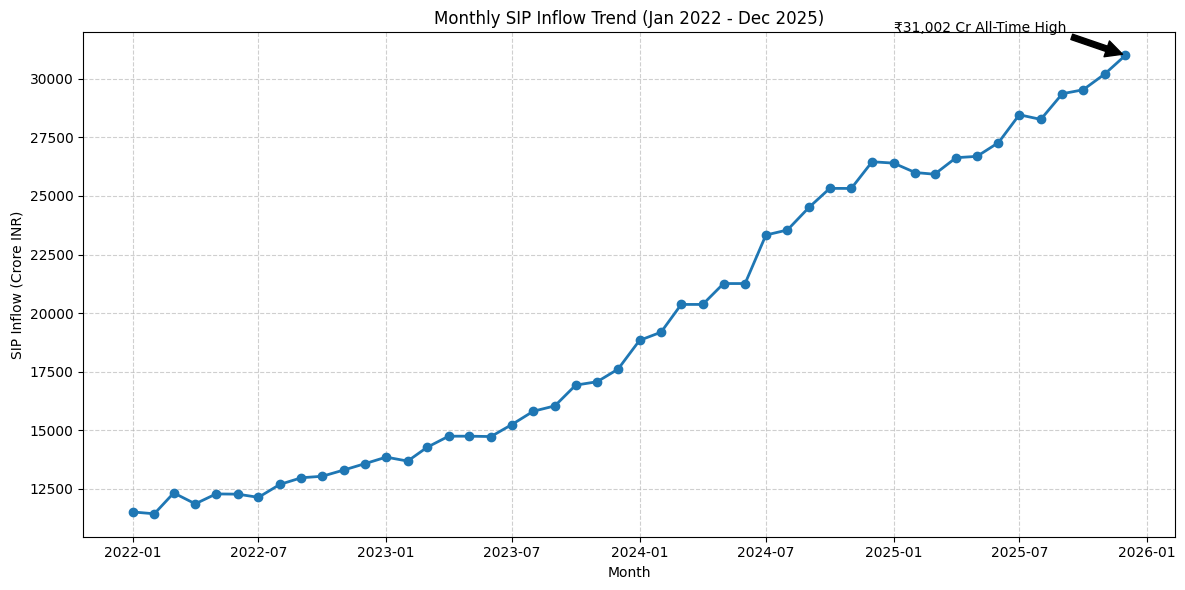

In [4]:
df_sip = pd.read_sql_query("SELECT month, sip_inflow_crore FROM fact_sip_industry", conn)
df_sip['month'] = pd.to_datetime(df_sip['month'] + '-01')

plt.figure(figsize=(12, 6))
plt.plot(df_sip['month'], df_sip['sip_inflow_crore'], marker='o', color='tab:blue', linewidth=2)
plt.annotate("₹31,002 Cr All-Time High", xy=(pd.to_datetime("2025-12-01"), 31002),
             xytext=(pd.to_datetime("2025-01-01"), 32000),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.title('Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore INR)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('reports/sip_inflow.png')
plt.show()

## 4. Category Inflow Heatmap
**Insight 4:** Equity funds (especially Large Cap and Small Cap) have seen the heaviest inflows compared to debt and hybrid categories, signaling strong retail risk appetite.

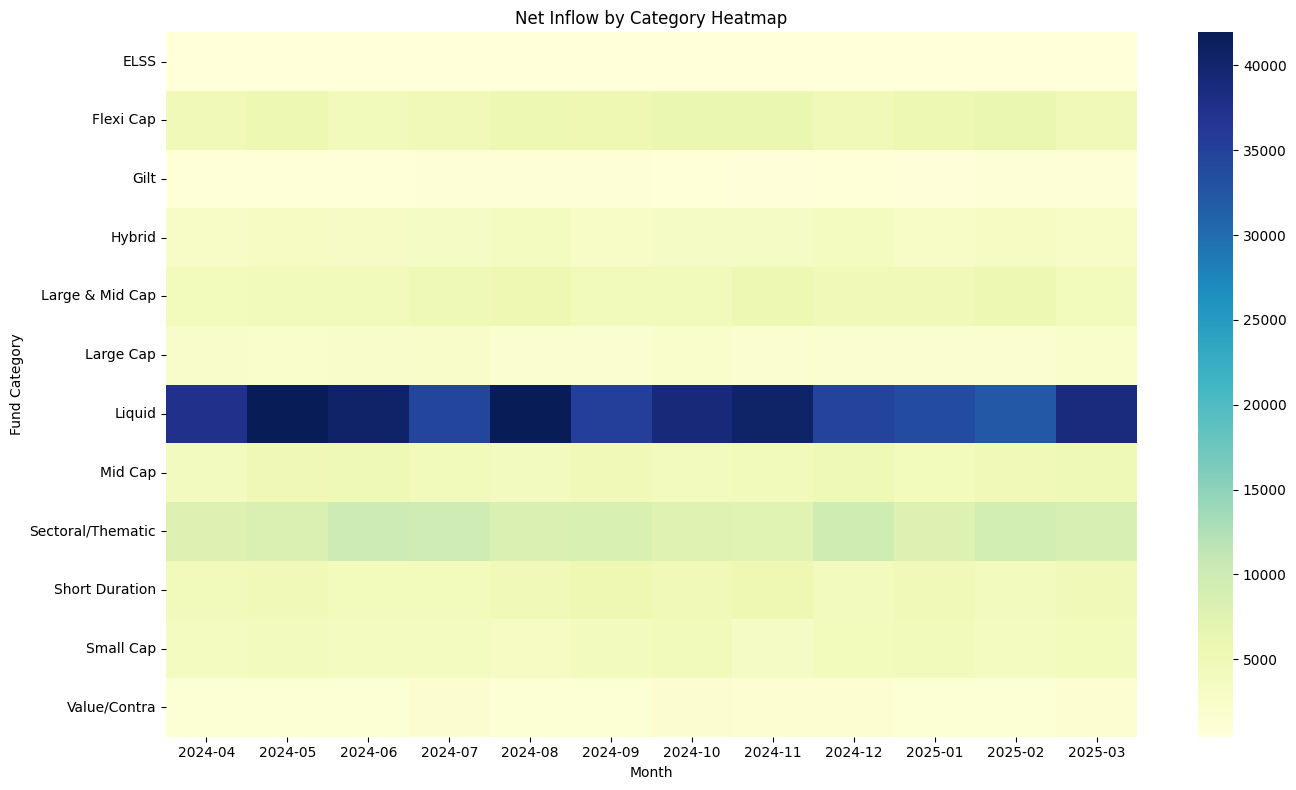

In [5]:
df_cat = pd.read_csv('data/processed/clean_category_inflows.csv')
df_cat_heatmap = df_cat.pivot(index='month', columns='category', values='net_inflow_crore')

plt.figure(figsize=(14, 8))
sns.heatmap(df_cat_heatmap.T, cmap='YlGnBu', annot=False)
plt.title('Net Inflow by Category Heatmap')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.tight_layout()
plt.savefig('reports/category_heatmap.png')
plt.show()

## 5. Investor Demographics
**Insight 5:** The 26-35 age group constitutes the largest demographic slice and maintains the highest median SIP amount, highlighting young professionals driving market growth.
**Insight 6:** Male investors account for a disproportionately large share of SIPs, indicating a need for targeted financial inclusion for women.

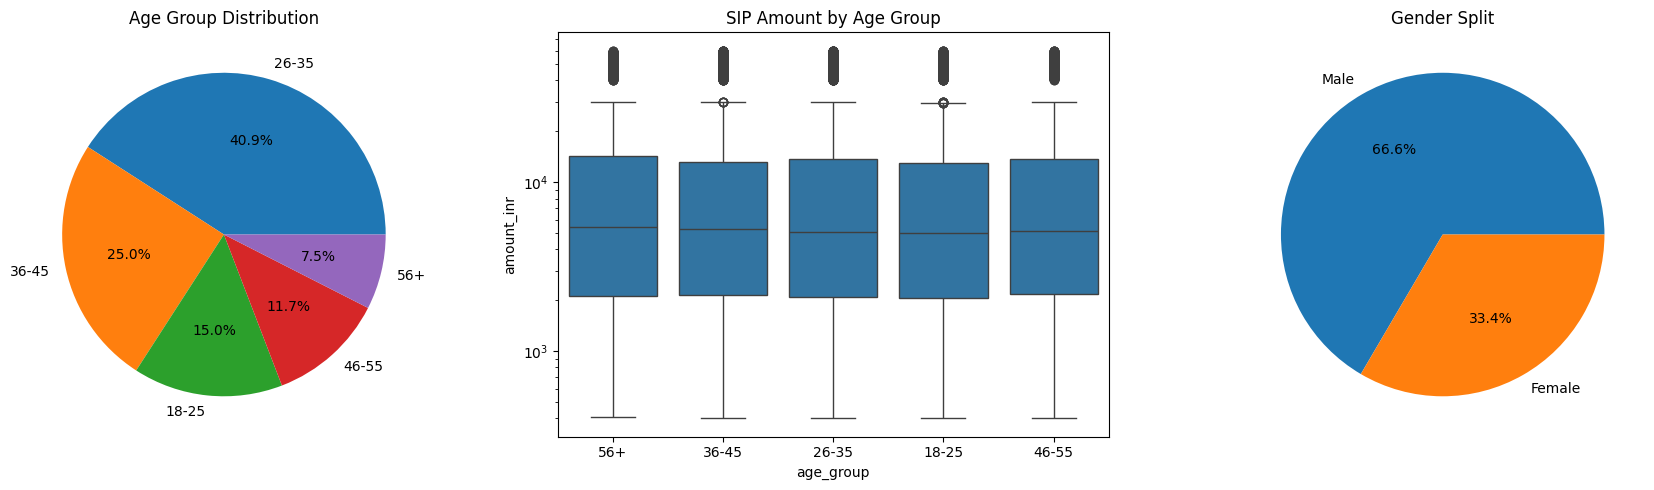

In [6]:
df_tx = pd.read_sql_query("SELECT age_group, amount_inr, gender FROM fact_transactions WHERE transaction_type='SIP'", conn)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age group pie
age_counts = df_tx['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')
axes[0].set_title('Age Group Distribution')

# SIP Boxplot
sns.boxplot(data=df_tx, x='age_group', y='amount_inr', ax=axes[1])
axes[1].set_title('SIP Amount by Age Group')
axes[1].set_yscale('log')

# Gender split
gender_counts = df_tx['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
axes[2].set_title('Gender Split')

plt.tight_layout()
plt.savefig('reports/demographics.png')
plt.show()

## 6. Geographic Distribution
**Insight 7:** T30 (Top 30) cities still contribute the vast majority of SIP inflows, though B30 (Beyond 30) cities are showing rapid adoption.

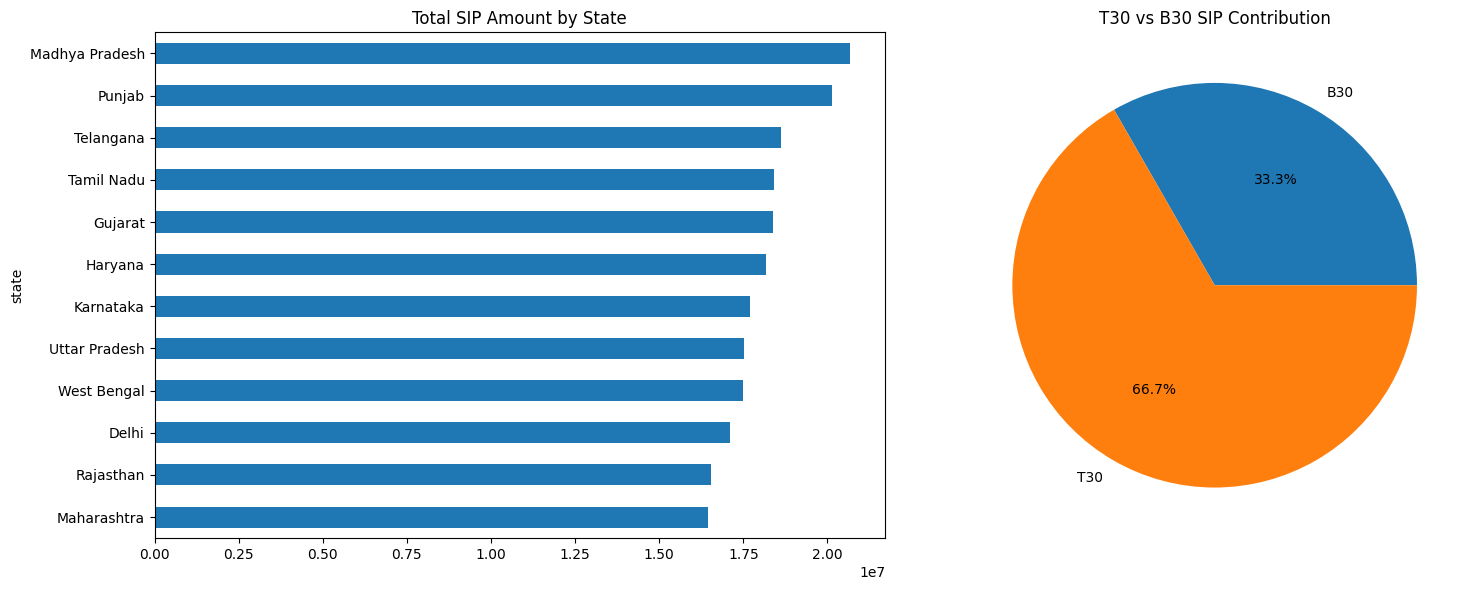

In [7]:
df_geo = pd.read_sql_query("SELECT state, city_tier, amount_inr FROM fact_transactions WHERE transaction_type='SIP'", conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# State bar chart
state_amt = df_geo.groupby('state')['amount_inr'].sum().sort_values(ascending=True)
state_amt.plot(kind='barh', ax=axes[0], color='tab:blue')
axes[0].set_title('Total SIP Amount by State')

# City Tier Pie
tier_counts = df_geo.groupby('city_tier')['amount_inr'].sum()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%')
axes[1].set_title('T30 vs B30 SIP Contribution')

plt.tight_layout()
plt.savefig('reports/geographic.png')
plt.show()

## 7. Folio Count Growth
**Insight 8:** Industry folio count nearly doubled in 4 years, surging from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025.

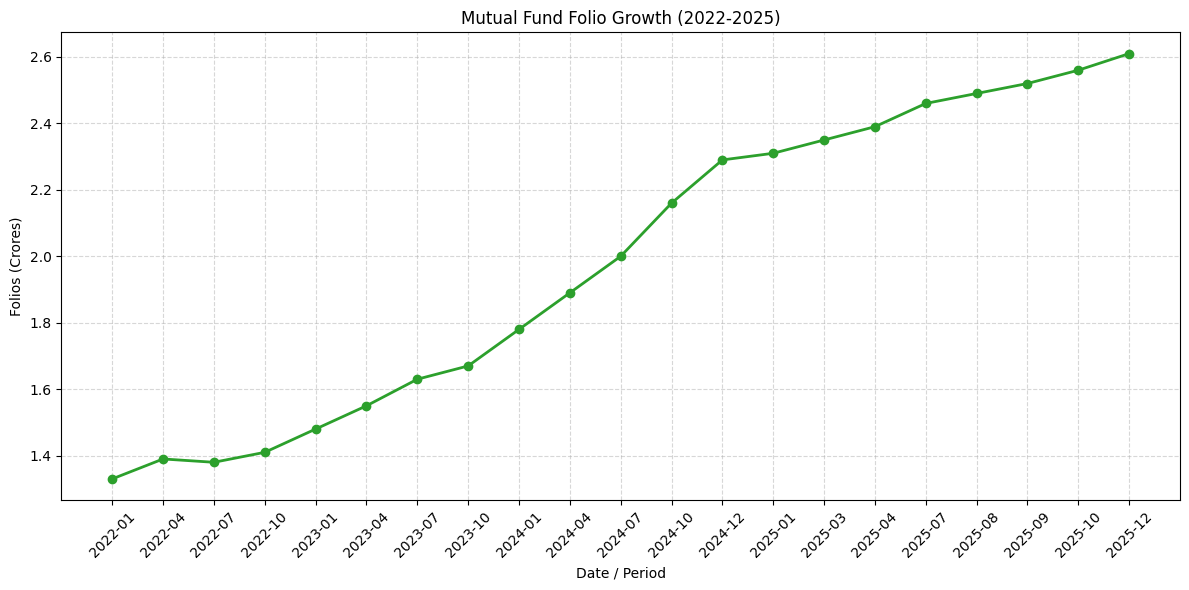

In [8]:
df_folio = pd.read_csv('data/processed/clean_industry_folio_count.csv')

plt.figure(figsize=(12, 6))
x_col = df_folio.columns[0]
y_col = df_folio.columns[-1]
plt.plot(df_folio[x_col], df_folio[y_col], marker='o', color='tab:green', linewidth=2)
plt.title('Mutual Fund Folio Growth (2022-2025)')
plt.xlabel('Date / Period')
plt.ylabel('Folios (Crores)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('reports/folio_growth.png')
plt.show()

## 8. NAV Return Correlation Matrix
**Insight 9:** Funds within the same category (e.g., Large Cap) exhibit near-perfect positive correlation, underscoring the lack of diversification when holding similar schemes.

C:\Users\Arnav\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\Arnav\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


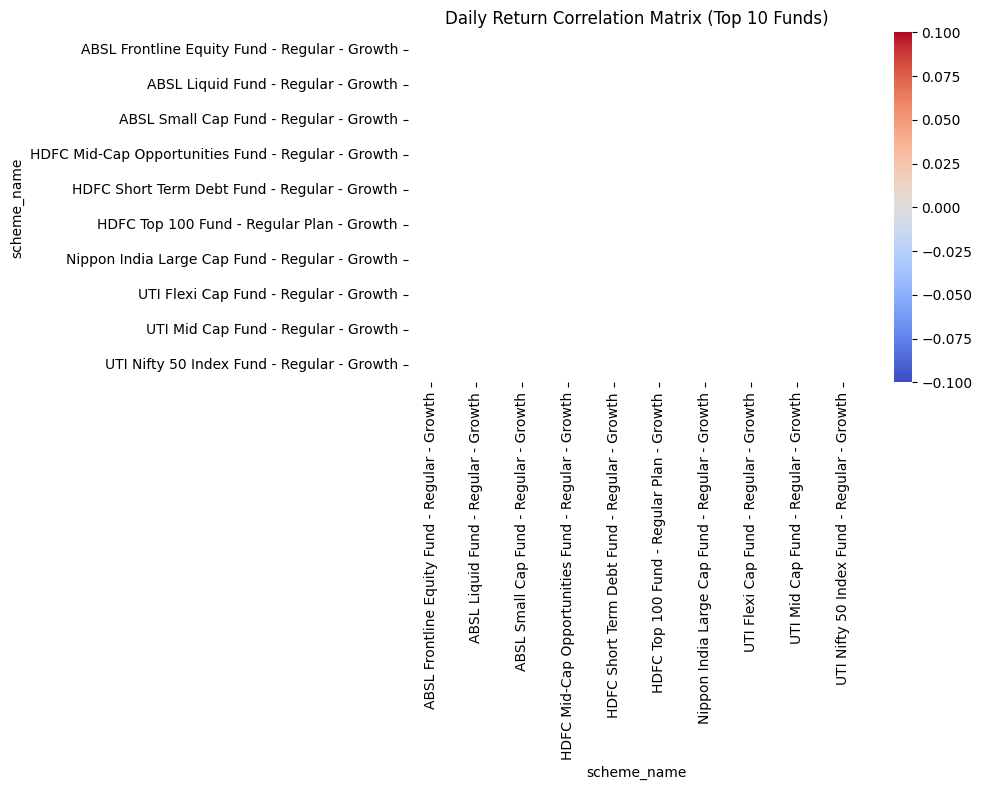

In [9]:
query = '''
SELECT f.scheme_name, n.date, n.daily_return_pct 
FROM fact_nav n 
JOIN dim_fund f ON n.amfi_code = f.amfi_code 
WHERE f.scheme_name IN (SELECT scheme_name FROM dim_fund LIMIT 10)
'''
df_corr = pd.read_sql_query(query, conn)
df_pivot = df_corr.pivot(index='date', columns='scheme_name', values='daily_return_pct')

plt.figure(figsize=(10, 8))
sns.heatmap(df_pivot.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Daily Return Correlation Matrix (Top 10 Funds)')
plt.tight_layout()
plt.savefig('reports/correlation_matrix.png')
plt.show()

## 9. Sector Allocation Donut
**Insight 10:** The Financial Services and Banking sectors heavily dominate equity mutual fund portfolios, representing the largest systemic sector bet.

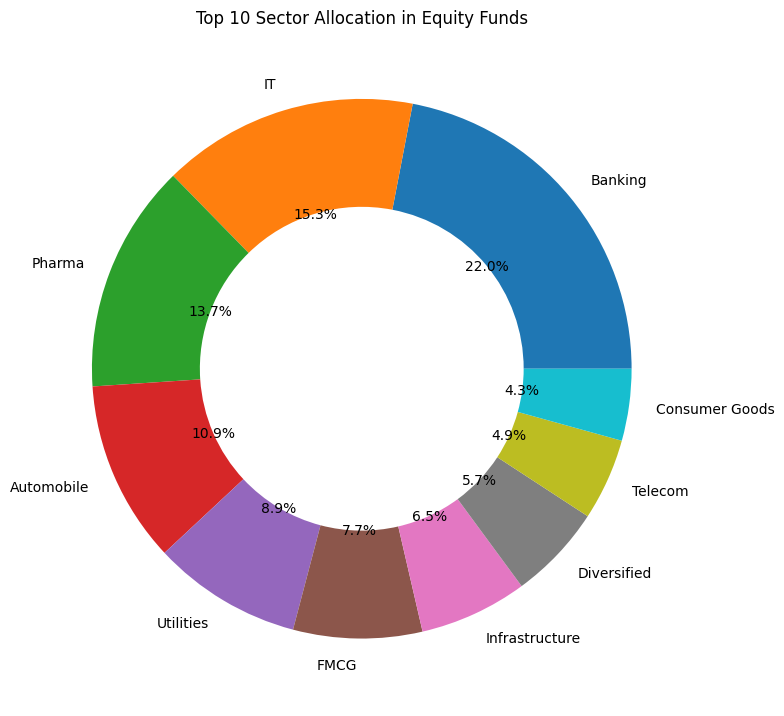

In [10]:
df_port = pd.read_sql_query("SELECT sector, weight_pct FROM fact_portfolio", conn)
sector_weights = df_port.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 8))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', wedgeprops=dict(width=0.4))
plt.title('Top 10 Sector Allocation in Equity Funds')
plt.tight_layout()
plt.savefig('reports/sector_allocation.png')
plt.show()

In [11]:
conn.close()